In [109]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from scipy.stats import skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy import stats
warnings.filterwarnings('ignore')

In [110]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result

In [111]:
def detection_of_bullish_belt_hold(data, body_rate=0.5):
    """
    Обнаружение бычьего паттерна "Захват за пояс" (Bullish Belt Hold) и генерация торгового сигнала.
    
    Паттерн "Бычий захват за пояс" - это односвечная модель разворота, которая формируется
    на нисходящем тренде и сигнализирует о потенциальном развороте вверх.
    
    Характеристики паттерна:
        - Цена открытия (open) равна минимуму свечи (low) — нет нижней тени
        - Тело свечи большое (занимает >50% от всего диапазона свечи)
        - Цена закрытия (close) находится в верхней части свечи
        - Верхняя тень может присутствовать, но обычно небольшая
    
    Логика работы функции:
        1. Проверяется условие: open == low (нет нижней тени)
        2. Тело свечи > 0 (открытие и закрытие не равны)
        3. Соотношение тела ко всему диапазону свечи > body_rate (по умолчанию >50%)
        4. Если условия выполнены — свеча помечается как паттерн 'Bullish Belt Hold'
        5. Торговый сигнал (signal = 1) генерируется НА СЛЕДУЮЩЕЙ свече
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            - open (float): Цена открытия
            - high (float): Максимальная цена
            - low (float): Минимальная цена
            - close (float): Цена закрытия
        body_rate (float, default=0.5): Минимальное допустимое соотношение тела свечи
                                        ко всему диапазону свечи (body / full_candle).
                                        По умолчанию 0.5 (тело ≥ 50% от всей свечи).
    
    Returns:
        pd.DataFrame: Исходный DataFrame с добавленными столбцами:
            - pattern (int): 1 — на текущей свече обнаружен паттерн "Bullish Belt Hold";
                             0 — паттерн отсутствует.
            - signal (int): 1 — торговый сигнал на покупку на следующей свече;
                            0 — сигнала нет.
            - body_rate (float): Скопированное значение параметра body_rate.
            - strategy (str): Название стратегии — всегда 'bullish_belt_hold'.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['body_rate'] = body_rate
    data['lower_shadow_rate'] = 0
    data['up_shadow_rate'] = 0
    data['strategy'] = 'bullish_belt_hold'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = data['close'] - data['open']
    
    
    # Базовое условие для формации молот
    mask = ((data['low'] == data['open']) & (body > 0) & (np.abs(body) / full_candle > body_rate))

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data


In [112]:
def detection_of_maribozy(data):
    """
    Обнаружение бычьего паттерна Марибозу.
    
    Паттерн: бычья свеча с минимальными тенями (допуск 0.1% от цены).
    
    Returns:
        - pattern: 1 - найден марибозу
        - strategy: 'maribozy'
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'maribozy'
    data['body_rate'] = 0
    data['lower_shadow_rate'] = 0
    data['up_shadow_rate'] = 0
    

    # Базовое условие для формации марибозу
    mask = ((data['close'] - data['open'] > 0) & 
                      (np.abs(data['open'] - data['low']) / data['open'] < 0.01) & 
                      (np.abs(data['close'] - data['high']) / data['close'] < 0.01))

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    return data

In [113]:
def detection_of_dodji(data, body_rate=0.1):
    """
    Обнаружение паттерна "Доджи" (Doji) и генерация торгового сигнала.
    
    Паттерн "Доджи" - это свечной паттерн неопределённости, который формируется,
    когда цена открытия и закрытия практически равны. Он сигнализирует о равенстве
    сил покупателей и продавцов и часто предвещает разворот или нестабильность тренда.
    
    Характеристики паттерна:
        - Тело свечи очень маленькое по сравнению со всем диапазоном свечи
        - Цена открытия и закрытия находятся на одном уровне (или очень близко)
        - Может иметь длинные верхнюю и/или нижнюю тени
    
    Логика работы функции:
        1. Вычисляется соотношение тела свечи к полному диапазону (high - low).
        2. Если это соотношение меньше body_rate — свеча помечается как паттерн 'Доджи'.
        3. Торговый сигнал (signal = 1) генерируется НА СЛЕДУЮЩЕЙ свече.
    
    Параметры паттерна:
        - Тело свечи занимает небольшую часть от всего диапазона (по умолчанию ≤ 10%)
        - Нижняя и верхняя тени могут быть любыми (классический Доджи допускает любые тени)
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            - open (float): Цена открытия
            - high (float): Максимальная цена
            - low (float): Минимальная цена
            - close (float): Цена закрытия
        body_rate (float, default=0.1): Максимальное допустимое соотношение тела свечи
                                        ко всему диапазону свечи (body / full_candle).
                                        По умолчанию 0.1 (тело ≤ 10% от всей свечи).
    
    Returns:
        pd.DataFrame: Исходный DataFrame с добавленными столбцами:
            - pattern (int): 1 — на текущей свече обнаружен паттерн "Доджи";
                             0 — паттерн отсутствует.
            - signal (int): 1 — торговый сигнал на следующей свече;
                            0 — сигнала нет.
            - body_rate (float): Скопированное значение параметра body_rate.
            - strategy (str): Название стратегии — всегда 'dodji'.
    

    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['body_rate'] = body_rate
    data['lower_shadow_rate'] = 0
    data['up_shadow_rate'] = 0
    data['strategy'] = 'dodji'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = np.abs(data['close'] - data['open'])

    

    # Базовое условие для формации молот
    mask = (body / full_candle < body_rate)

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [114]:
def detection_of_hammer(data, lower_shadow_rate=2, body_rate=0.3, up_shadow_rate=0.1):

    """
    Обнаружение бычьего паттерна "Молот" (Hammer).
    
    Паттерн "Молот" - это односвечная модель разворота, которая формируется на нисходящем тренде
    и сигнализирует о потенциальном развороте вверх. Характеризуется маленьким телом в верхней
    части свечи и длинной нижней тенью.
    
    Параметры паттерна:
        - Тело свечи занимает небольшую часть от всего диапазона (по умолчанию ≤30%)
        - Нижняя тень значительно длиннее тела (по умолчанию ≥2 * тела)
        - Верхняя тень минимальна или отсутствует (по умолчанию ≤ 0.1 * тела)
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            - open (float): Цена открытия
            - high (float): Максимальная цена
            - low (float): Минимальная цена
            - close (float): Цена закрытия
        lower_shadow_rate (float): Минимальное соотношение нижней тени к телу.
                                   По умолчанию 2 (нижняя тень > 2 * тела).
        body_rate (float): Максимальное соотношение тела ко всей свече.
                           По умолчанию 0.3 (тело < 30% свечи).
        up_shadow_rate (float): Максимальное соотношение верхней тени к телу.
                                По умолчанию 1 (верхняя тень < 0.1 * тела).
    
    Returns:
        pd.DataFrame: Исходный DataFrame с дополнительными столбцами:
            - pattern (int): 1 - обнаружен паттерн "Молот" на текущей свече,
                             0 - паттерн отсутствует
            - strategy (str): Название стратегии - 'hummer'
    
"""
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['lower_shadow_rate'] = lower_shadow_rate
    data['up_shadow_rate'] = up_shadow_rate
    data['body_rate'] = body_rate
    data['strategy'] = 'hammer'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = np.abs(data['close'] - data['open'])
    lower_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    

    # Базовое условие для формации молот
    mask = ((body / full_candle < body_rate) & 
                      (lower_shadow / body > lower_shadow_rate) &
                      (up_shadow / body < up_shadow_rate))

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data


In [115]:
def detection_of_inverted_hammer(data, lower_shadow_rate=0.1, body_rate=0.3, up_shadow_rate=2):

    """
    Обнаружение паттерна "Перевернутый молот".
    
    Условия:
        - Тело свечи ≤ 30% от всей свечи
        - Верхняя тень ≥ 10% от тела
        - Нижняя тень ≤ 2× тела
    
    Args:
        data: DataFrame с колонками open, high, low, close
        lower_shadow_rate: макс. соотношение нижней тени к телу (по умолч. 0.1)
        body_rate: макс. соотношение тела к свече (по умолч. 0.3)
        up_shadow_rate: мин. соотношение верхней тени к телу (по умолч. 2)
    
    Returns:
        data с колонками:
            - pattern: 1 - найден паттерн
            - signal: 1 - сигнал на покупку (на следующей свече)
            - strategy: 'inverted_hammer'
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['lower_shadow_rate'] = lower_shadow_rate
    data['up_shadow_rate'] = up_shadow_rate
    data['body_rate'] = body_rate
    data['strategy'] = 'inverted_hammer'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = np.abs(data['close'] - data['open'])
    lower_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    

    # Базовое условие для формации перевернутый молот
    mask = ((body / full_candle < body_rate) & 
                      (lower_shadow / body < lower_shadow_rate) &
                      (up_shadow / body > up_shadow_rate))

    
    data.loc[mask, 'pattern'] = 1

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [116]:
# Специальная функция для проверки эффективности паттернов 
def filter_min_distance(data, column, N):
    """Некоторые паттерны расположены слишком близко друг к другу, чтобы не было наложения сделок, 
    необходимо удалить все сигналы на покупку, которые появляются во время удержания позиции.
    Время удержания N периодов

    Args:
        data (pd.DataFrame): Преобразованный датафрейм
        'signal' (int64): Сигнальный столбец.
        N (int): Количество периодов, которые мы собираемся удерживать открытую позицию

    Returns:
        data (pd.DataFrame): Исходный датафрейм с отредактированным сигнальным столбцом
    """
    data = data.copy()
    # Получаем все индексы наблюдений где у нас есть сигнал на покупку
    one_index = data[data[column] == 1].index 
    # Получаем разность между этими индексами
    distances = np.diff(one_index)
    # Маска для каждого сигнала. Первый сигнал на покупку всегда True
    mask = [True]
    
    # Перебираем все разности между индексами
    for dist in distances:
        if dist >= N:
            # Если разность между индексами больше N, то все хорошо.
            # Мы добавляем эту сделку в список
            mask.append(True)
        else:
            # Если расстояние меньше, то сделку игнорируем
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data

In [117]:
# Готовим данные для дальнейшей проверки
def data_prepare_for_statistics_1candle(data, commission=0.00085):
    """Функция предназначена для обработки результатов стратегий.

    Args:
        data (pd.DataFrame): на вход подается размеченный датафрейм с колонкой 'signal'
        commission (float, optional): Размер комисии в долях процента (0.00085 ~ 0.085%). Defaults to 0.00085.

    Returns:
        list: Возвращаем список с датафреймами, каждый датафрейм это данные по каждой сделке (дата и размер прибыли в %)
    """
    data = data.copy()
    # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
    data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0
    
    # Проходимся циклом по периодам удержания позиции
    all_strategy = []
    for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
        data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
        data_h = data_h.set_index('time')
        # Блок для определения цены входа и выхода
        # То есть для каждой стратегии мы определяем вектора цен открытий и закрытий
        # Так как удерживаем позицию мы N периодов, то в качестве всех кандидатов, 
        # на которых мы можем закрыть позицию берем цены открытия через N периодов
        
        exit_candidate = data_h['open'].shift(-N) 
        is_entry = data_h['signal'] == 1
        entry_price = data_h['open'][is_entry]
        exit_price = exit_candidate[is_entry]
        
        # Считаем результат
        gross_profit = exit_price.values - entry_price.values
        commissions = exit_price.values * commission + entry_price.values * commission
        net_profit = gross_profit - commissions
        percent_profit_net = pd.Series(np.round(net_profit / entry_price.values, 5), index=entry_price.index,
                               name='profit_percent') # % доход за сделку
        percent_profit_without_commission = pd.Series(np.round(gross_profit / entry_price.values, 5), index=entry_price.index,
                               name='gross_profit_percent') # % доход за сделку грязный
        
        strategy_data = pd.DataFrame({'profit_percent_net' : np.array(percent_profit_net), 
                                      'percent_profit_without_commission' : np.array(percent_profit_without_commission),
                                       'N' : N, 
                                       'strategy_name' : data_h['strategy'].iloc[0],
                                       'ticker' : data_h['ticker'].iloc[0],
                                       'period' : data_h['per'].iloc[0],
                                       'body_rate' : data_h['body_rate'].iloc[0],
                                       'lower_shadow_rate' : data_h['lower_shadow_rate'].iloc[0],
                                       'up_shadow_rate' : data_h['up_shadow_rate'].iloc[0]},
                            index=percent_profit_net.index)
        all_strategy.append(strategy_data)
        
    return all_strategy



In [118]:
# Функция для получения результатов стратегии
def trade_statistics_bull(all_strategy_data):
    """Функция предназначена для агрегирования результатов стратегий по основным финансовым метрикам

    Args:
        all_strategy_data (list): Подаётся список с датафреймами, где для для каждой сделки установлено время и размер прибыли в %.

    Returns:
        data (pd.DataFrame): Возвращаем новый датафрейм со всеми необходимыми метриками для оценки стратегий.
    """
    capital = 100_000
    strategies = []
    for strategy in all_strategy_data:
        
        # Считаем основные метрики
        ticker = strategy['ticker'].iloc[0]
        strategy_name = strategy['strategy_name'].iloc[0]
        period = strategy['period'].iloc[0]
        N = strategy['N'].iloc[0]
        body_rate = strategy['body_rate'].iloc[0]
        lower_shadow_rate = strategy['lower_shadow_rate'].iloc[0]
        up_shadow_rate = strategy['up_shadow_rate'].iloc[0]
        count_of_trades = len(np.array(strategy['profit_percent_net']))
        profit_percent_net = strategy['profit_percent_net']
        percent_profit_without_commission = strategy['percent_profit_without_commission']
        
        # Кривая капитала 
        capital_curve_net = capital * np.cumprod(1 + strategy['profit_percent_net'])
        capital_curve_without_commission = capital * np.cumprod(1 + strategy['percent_profit_without_commission'])
        
        # Профит фактор
        pr_per_net = np.array(strategy['profit_percent_net'])
        profit_factor = np.round(np.sum(pr_per_net[pr_per_net > 0]) / np.abs(np.sum(pr_per_net[pr_per_net < 0])), 3)
        
        # Общий % доход !!!
        total_per_return_r = np.array(np.cumprod(1 + strategy['profit_percent_net']))[-1]
        total_per_return = np.round((total_per_return_r - 1) * 100, 2)
        
        # Win_rate 
        win_rate = np.round(np.mean(pr_per_net > 0), 2)
        
        # R2
        X = np.array(list(range(len(capital_curve_net)))).reshape(-1, 1)
        y = np.array(capital_curve_net)
        lin = LinearRegression()
        lin.fit(X, y)
        y_pred = lin.predict(X)
        r2 = np.round(metrics.r2_score(y, y_pred), 2)
        
        # Средняя убыточная и прибыльная сделка 
        mean_profit_trade = np.round(np.mean(pr_per_net[pr_per_net > 0]), 3)
        mean_loss_trade = np.round(np.mean(pr_per_net[pr_per_net < 0]), 3)
        avg_profit_loss_ratio = np.round(mean_profit_trade / mean_loss_trade, 3)
        
        # Максимальная просадка
        cumsum_profit = np.cumsum(pr_per_net)
        cummax_profit = np.maximum.accumulate(cumsum_profit)
        max_drawdown = np.max(cummax_profit - cumsum_profit)
        
        strategies.append({
          'ticker' : ticker,
          'strategy name' : strategy_name,
          'period' : period,
          'N' : N,
          'body_rate' : body_rate,
          'lower_shadow_rate' : lower_shadow_rate,
          'up_shadow_rate' : up_shadow_rate,
          'count of trades' : count_of_trades,
          'profit factor' : profit_factor,
          'total percent return' : total_per_return,
          'R2' : r2,
          'win_rate' : win_rate,
          'mean profit (%)' : mean_profit_trade * 100,
          'mean loss (%)' : mean_loss_trade * 100,
          'profit/loss ratio' : np.round(np.abs(avg_profit_loss_ratio), 2),
          'max drawdown (%)' : np.round(max_drawdown * 100, 1),
          'capital curve net' : capital_curve_net,
          'capital curve without commission' : capital_curve_without_commission,
          'profit percent net' : profit_percent_net,
          'percent profit without commission' : percent_profit_without_commission}
          )
        
    return pd.DataFrame(strategies)


In [119]:
# Проверяем стратегии на множестве ТФ.
def backtest_strategies_multi_tf():
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    l = []
    # Перебираем все тф
    for a in [
              r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\PLZL.txt']:
        data = pd.read_csv(a)
        for i in ['1h','D']:
            data_tm = good_dataframe(data, i)
            l.append(data_tm)
        
        all_strategy = []
        # Для каждого тф проверяем стратегию бычье поглощение
        for j in l:
            for func in [detection_of_bullish_belt_hold, detection_of_maribozy]:
                if func == detection_of_bullish_belt_hold:
                    for body_rate in [0.5, 0.6, 0.7, 0.8, 0.9]:
                        detection_data = func(j, body_rate=body_rate)
                        result = data_prepare_for_statistics_1candle(detection_data)
                        final_result = trade_statistics_bull(result)
                        all_strategy.append(final_result)
                else:
                    detection_data = func(j)
                    result = data_prepare_for_statistics_1candle(detection_data)
                    final_result = trade_statistics_bull(result)
                    all_strategy.append(final_result)
        # Объединяем результат   
        combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

sber_result_strategies = backtest_strategies_multi_tf()
sber_result_strategies.head(3)

,ticker,strategy name,period,N,body_rate,lower_shadow_rate,up_shadow_rate,count of trades,profit factor,total percent return,R2,win_rate,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission
0,PLZL,bullish_belt_hold,1h,1,0.5,0,0,2166,0.406,-98.37,0.77,0.25,0.5,-0.4,1.25,412.2,time 2009-01-11 18:00:00 101420.000000 2009...,time 2009-01-11 18:00:00 101591.000000 2009...,time 2009-01-11 18:00:00 0.01420 2009-01-26...,time 2009-01-11 18:00:00 0.01591 2009-01-26...
1,PLZL,bullish_belt_hold,1h,2,0.5,0,0,2021,0.536,-97.20,0.74,0.30,0.7,-0.5,1.40,360.6,time 2009-01-11 18:00:00 103350.000000 2009...,time 2009-01-11 18:00:00 103523.000000 2009...,time 2009-01-11 18:00:00 0.03350 2009-01-26...,time 2009-01-11 18:00:00 0.03523 2009-01-26...
2,PLZL,bullish_belt_hold,1h,3,0.5,0,0,1875,0.633,-95.55,0.81,0.33,0.8,-0.6,1.33,313.9,time 2009-01-11 18:00:00 103606.000000 2009...,time 2009-01-11 18:00:00 103779.000000 2009...,time 2009-01-11 18:00:00 0.03606 2009-01-26...,time 2009-01-11 18:00:00 0.03779 2009-01-26...


In [120]:
# desired_columns = ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']
# desired_index = ['maribozy',
#                  'bullish_belt_hold',
#                  'dodji',
#                  'hammer',
#                  'inverted_hammer'
# ]
# index_rus = {
#     'maribozy' : 'Марибозу - лонг',
#     'bullish_belt_hold' : 'Бычий захват за пояс',
#     'dodji' : 'Доджи - лонг',
#     'hammer' : 'Молот - лонг',
#     'inverted_hammer' : 'Перевернутый молот - лонг'
# }
# dt = pd.pivot_table(data=sber_result_strategies[sber_result_strategies['count of trades'] > 600],
#                values='total percent return',
#                index='strategy name',
#                columns='period',
#                aggfunc='max',
#                fill_value=0)
# dt = dt.rename(index=index_rus)
# sns.heatmap(dt, annot=True, fmt='.0f')
# plt.title('Доходность бычьих односвечных паттернов по таймфреймам, % (Сургутнефтегаз)', pad=20)
# plt.xlabel('Таймфрейм')
# plt.ylabel('Паттерн');

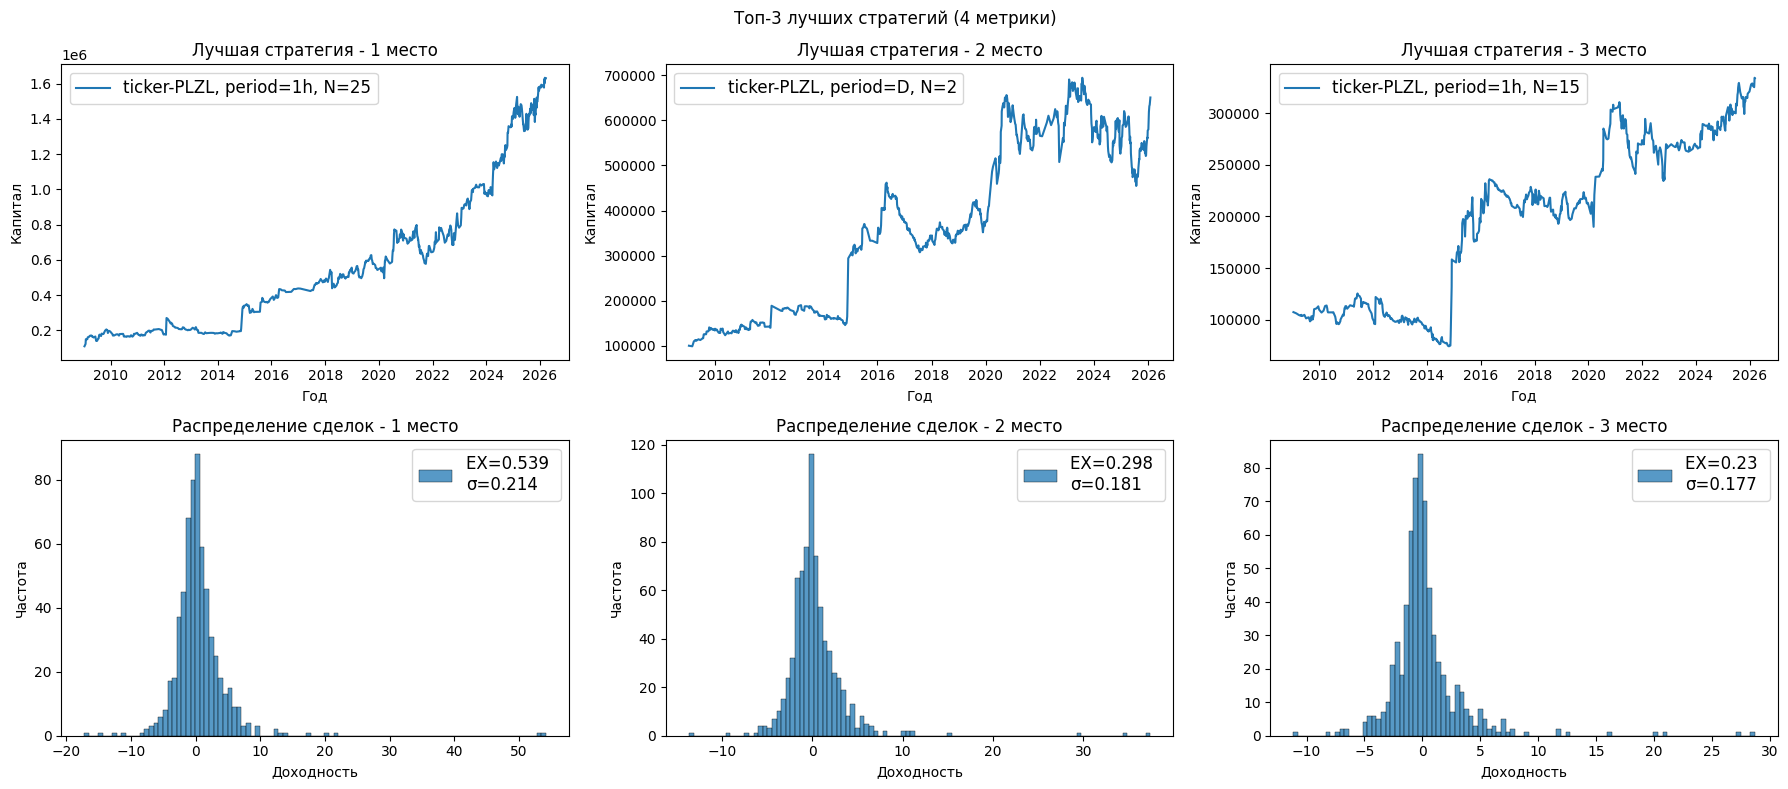

,ticker,strategy name,period,N,body_rate,count of trades,profit factor,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),total percent return,R2,win_rate
0,PLZL,bullish_belt_hold,1h,25,0.5,625,1.558,2.9,-2.0,1.45,43.8,1530.73,0.91,0.52
1,PLZL,maribozy,D,2,0.0,755,1.384,2.3,-1.5,1.53,40.2,550.73,0.82,0.47
2,PLZL,bullish_belt_hold,1h,15,0.8,657,1.295,2.3,-1.4,1.64,47.0,233.86,0.86,0.45


In [121]:
# Функция для первичного отбора стратегий
def compare_strategies(data):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
    Returns:
        data (pd.DaraFrame): Возвращаем отфильтрованный датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[(data['count of trades'] > 600) & (data['profit factor'] > 1) & (data['R2'] > 0.6) & (data['max drawdown (%)'] < 50)] # Ограничение по количеству сделок
    if data.shape[0] != 0:
        data['profit factor rank'] = data['profit factor'].rank() # Больше лучше
        data['R2 rank'] = data['R2'].rank() # Больше лучше
        data['profit/loss ratio rank'] = data['profit/loss ratio'].rank() # Больше лучше
        data['max drawdown rank'] = data['max drawdown (%)'].rank(ascending=False) # Меньше лучше
        data['best model'] = data['profit factor rank'] + data['R2 rank'] + data['profit/loss ratio rank'] + data['max drawdown rank']
        
        # Построение графиков 3 лучших стратегий
        
        data.sort_values('best model', ascending=False, inplace=True, ignore_index=True)
        if data.shape[0] >= 3:    
            # График
            fig, axes = plt.subplots(2, 3, figsize=(18, 8))
            plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
            
            # Первые 3 графика
            sns.lineplot(data.loc[0, 'capital curve net'], ax=axes[0, 0], label=f'ticker-{data.loc[0, 'ticker']}, period={data.loc[0, 'period']}, N={data.loc[0, 'N']}');
            sns.lineplot(data.loc[1, 'capital curve net'], ax=axes[0, 1], label=f'ticker-{data.loc[1, 'ticker']}, period={data.loc[1, 'period']}, N={data.loc[1, 'N']}');
            sns.lineplot(data.loc[2, 'capital curve net'], ax=axes[0, 2], label=f'ticker-{data.loc[2, 'ticker']}, period={data.loc[2, 'period']}, N={data.loc[2, 'N']}');
            axes[0, 0].legend(fontsize=12)
            axes[0, 1].legend(fontsize=12)
            axes[0, 2].legend(fontsize=12)
            
            axes[0, 0].set_title('Лучшая стратегия - 1 место')
            axes[0, 1].set_title('Лучшая стратегия - 2 место')
            axes[0, 2].set_title('Лучшая стратегия - 3 место')
            axes[0, 0].set_ylabel('Капитал')
            axes[0, 1].set_ylabel('Капитал')
            axes[0, 2].set_ylabel('Капитал')
            axes[0, 0].set_xlabel('Год')
            axes[0, 1].set_xlabel('Год')
            axes[0, 2].set_xlabel('Год')
            
            # Вторые 3 графика
            sns.histplot(data.loc[0, 'profit percent net'] * 100, ax=axes[1, 0], bins=100, 
                            label=f'EX={np.round(np.mean(data.loc[0, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit percent net"])),3)}');
            sns.histplot(data.loc[1, 'profit percent net'] * 100, ax=axes[1, 1], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[1, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit percent net"])),3)}');
            sns.histplot(data.loc[2, 'profit percent net'] * 100, ax=axes[1, 2], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[2, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit percent net"])),3)}');
            axes[1, 0].legend(fontsize=12)
            axes[1, 1].legend(fontsize=12)
            axes[1, 2].legend(fontsize=12)
                
            axes[1, 0].set_title('Распределение сделок - 1 место')
            axes[1, 1].set_title('Распределение сделок - 2 место')
            axes[1, 2].set_title('Распределение сделок - 3 место')
            axes[1, 0].set_ylabel('Частота')
            axes[1, 1].set_ylabel('Частота')
            axes[1, 2].set_ylabel('Частота')
            axes[1, 0].set_xlabel('Доходность')
            axes[1, 1].set_xlabel('Доходность')
            axes[1, 2].set_xlabel('Доходность')
                
            plt.tight_layout()
            plt.show()
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'body_rate', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))       
            return data
        else:
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'body_rate', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))
            return data  
            
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')
    
res = compare_strategies(sber_result_strategies)

In [162]:
dt = res.loc[0, 'profit percent net'].to_frame().reset_index()
dt

,time,profit_percent_net
0,2009-01-11 18:00:00,0.09499
1,2009-01-26 12:00:00,0.12183
2,2009-01-30 12:00:00,0.21865
3,2009-02-06 12:00:00,-0.01063
4,2009-02-19 10:00:00,0.01167
...,...,...
620,2026-02-27 17:00:00,0.02952
621,2026-03-04 09:00:00,-0.01413
622,2026-03-09 20:00:00,0.02005
623,2026-03-13 12:00:00,-0.00137


In [143]:
plzl = good_dataframe(pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\PLZL.txt'), '1h')


In [182]:

plzl['capital'] = np.round(100_000 * plzl['close'] / plzl.loc[0, 'close'], 2)
dr = pd.merge(dt, plzl, how='left', on='time')

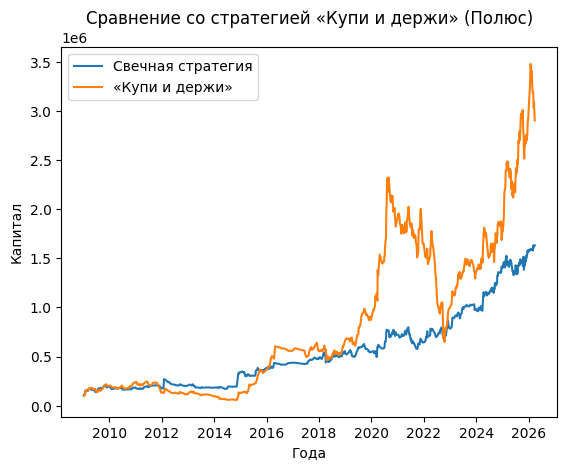

In [183]:

plt.title('Сравнение со стратегией «Купи и держи» (Полюс)')
sns.lineplot(y=(100_000 * np.cumprod(1 + dr['profit_percent_net'])), x=dr['time'], label='Свечная стратегия')
sns.lineplot(y=dr['capital'], x=dr['time'], label='«Купи и держи»')
plt.xlabel('Года')
plt.ylabel('Капитал');

In [127]:
plzl = pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\PLZL.txt')
buy = plzl.loc[0, '<OPEN>']
sell = plzl.loc[1995435, '<OPEN>']
plzl_res = np.round(sell/buy * 100, 1) 
print(plzl_res)

2645.5


In [128]:
res['buy and hold (%)'] = res['ticker'].map({'PLZL' : plzl_res})

In [129]:
res

,ticker,strategy name,period,N,body_rate,lower_shadow_rate,up_shadow_rate,count of trades,profit factor,total percent return,...,capital curve net,capital curve without commission,profit percent net,percent profit without commission,profit factor rank,R2 rank,profit/loss ratio rank,max drawdown rank,best model,buy and hold (%)
0,PLZL,bullish_belt_hold,1h,25,0.5,0,0,625,1.558,1530.73,...,time 2009-01-11 18:00:00 1.094990e+05 2009-...,time 2009-01-11 18:00:00 1.096780e+05 2009-...,time 2009-01-11 18:00:00 0.09499 2009-01-26...,time 2009-01-11 18:00:00 0.09678 2009-01-26...,3.0,3.0,1.0,2.0,9.0,2645.5
1,PLZL,maribozy,D,2,0.0,0,0,755,1.384,550.73,...,time 2009-01-13 100285.000000 2009-02-18 ...,time 2009-01-13 1.004550e+05 2009-02-18 ...,time 2009-01-13 0.00285 2009-02-18 -0.009...,time 2009-01-13 0.00455 2009-02-18 -0.007...,2.0,1.0,2.0,3.0,8.0,2645.5
2,PLZL,bullish_belt_hold,1h,15,0.8,0,0,657,1.295,233.86,...,time 2009-01-11 18:00:00 107467.000000 2009...,time 2009-01-11 18:00:00 1.076430e+05 2009-...,time 2009-01-11 18:00:00 0.07467 2009-02-19...,time 2009-01-11 18:00:00 0.07643 2009-02-19...,1.0,2.0,3.0,1.0,7.0,2645.5


In [130]:
sns

<module 'seaborn' from 'c:\\Users\\user\\Desktop\\Проект 1 года обучения\\project_1\\Lib\\site-packages\\seaborn\\__init__.py'>

In [131]:
2645.5/230

11.502173913043478

In [132]:
from scipy.stats import anderson, wilcoxon
from statsmodels.tsa.stattools import adfuller

ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК
ПАТТЕРН СЛУЧАЕН


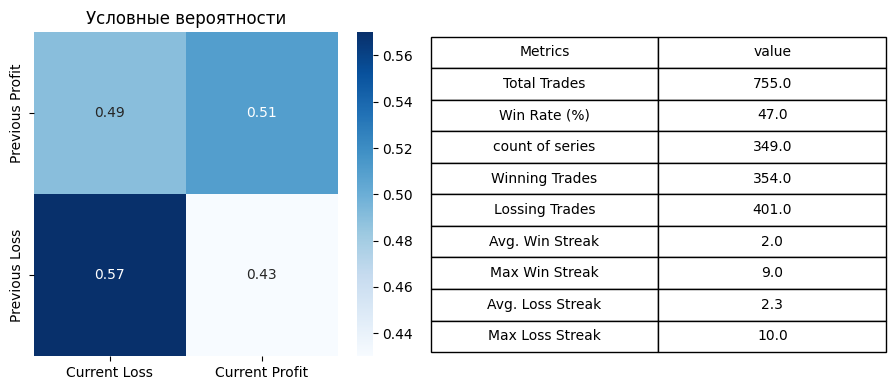

In [133]:
def run_analysis(lst):
    """Функция предназначена на статистического анализа торговой стратегии. Метрики, которые расчитываем:
    - Количество сделок всего, количество прибыльных/убыточных сделок
    - Количество серий (сколько раз был переход от прибыли к убытку и наоборот)
    - Средняя серия прибыльных/убыточных сделок
    - Максимальная серия прибыльных/убыточных сделок
    - Тест Вальда-Вольфовица для определения случайности в сериях сделок
    - Условные вероятности : P(W | W), P(W | L), P(L | W), P(L | L)

    Args:
        lst (list): Список чистых доходностей в %.

    Returns:
        Теловая карта с условными вероятностями и таблицу со всеми метриками.
    """
    if len(lst) > 0:
        lst_new = np.array(lst)
        lst_sign = (lst_new > 0).astype(int)
        n_win = np.sum(lst_sign) # Количество прибыльных сделок
        n_loss = len(lst_sign) - n_win # Количество убыточных сделок
        win_rate = np.round(n_win / len(lst_sign) * 100)
        
        # Считаем количество серий
        count_series = 1
        for i in range(1, len(lst_sign)):
            if lst_sign[i-1] != lst_sign[i]:
                count_series += 1
                
        # Считаем максимальное количество подряд идущих прибыльных сделок и среднюю серию прибыльных сделок
        list_win = []
        count_win = 0
        for i in range(len(lst_sign)):
            if lst_sign[i] == 1:
                count_win += 1
            else:
                if count_win != 0:
                    list_win.append(count_win)
                count_win = 0
        if count_win > 0:
            list_win.append(count_win) 
        
        mean_wins_series = np.round(np.mean(list_win), 1)
        max_wins_series = np.max(list_win)     
        
        # Считаем максимальное количество подряд идущих убыточных сделок и среднюю серию убыточных сделок
        list_loss = []
        count_loss = 0
        for i in range(1, len(lst_sign)):
            if lst_sign[i] == 0:
                count_loss += 1
            else:
                if count_loss != 0:
                    list_loss.append(count_loss)
                count_loss = 0
        if count_loss > 0:
            list_loss.append(count_loss)
        
        mean_loss_series = np.round(np.mean(list_loss), 1)
        max_loss_series = np.max(list_loss)
        
        
        # Проводим тест Вальда-Вольфовица для определения случайности в сериях сделок
        print('=' * 70)
        print('ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК')
        print('=' * 70)
        z_stat, p_value = runstest_1samp(lst_sign, correction=False)
        if p_value < 0.04:
            print('ПАТТЕРН НЕСЛУЧАЕН')
            if z_stat < 0:
                print('Наблюдается кластеризация, серии длиннее случайных.')
            else:
                print('Частое чередование (серии короче случайных).')
        else:
            print('ПАТТЕРН СЛУЧАЕН')
            
        # Условные вероятности
        df_usl = pd.DataFrame({'current' : lst_sign})
        df_usl['previous'] = df_usl['current'].shift(1)
        df_usl.dropna(inplace=True)
        Crosstable = np.round(pd.crosstab(columns=df_usl['current'], index=df_usl['previous'], normalize='index'), 2)
        Crosstable.index = ['Previous Loss', 'Previous Profit']
        Crosstable.columns = ['Current Loss', 'Current Profit']
        
        # Таблица с метриками
        final_data = pd.Series({'Total Trades' : len(lst_sign),
                                'Win Rate (%)' : win_rate,
                                'count of series' : count_series,
                                'Winning Trades' : n_win,
                                'Lossing Trades' : n_loss,
                                'Avg. Win Streak' : mean_wins_series,
                                'Max Win Streak' : max_wins_series,
                                'Avg. Loss Streak' : mean_loss_series,
                                'Max Loss Streak' : max_loss_series}).reset_index().rename(columns={'index' : 'Metrics', 0 : 'value'})
        
        # Вывод
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
        sns.heatmap(Crosstable, annot=True, cmap="Blues", ax=ax1)
        ax1.invert_yaxis()
        ax1.set_title('Условные вероятности')
        
        
        table = ax2.table(
            cellText=final_data.values,
            colLabels=final_data.columns,
            cellLoc='center',
            loc='center')
        ax2.axis('off')
        table.scale(1.2, 1.8)
        table.auto_set_font_size(False)
        plt.tight_layout()
        plt.show()


        
        return final_data
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')


ac = run_analysis(res.loc[1, 'profit percent net'])

ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)
Ряд стационарен

ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)
Лаг 1: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 2: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 3: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 4: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 5: Наличие автокорреляции - Да (p ≤ 0.05)

ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)
Уровень доверия: 5.0%: Распределение Не нормальное
Уровень доверия: 2.5%: Распределение Не нормальное
Уровень доверия: 1.0%: Распределение Не нормальное

СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ
МЕДИАНА: -0.17%
НЕТ оснований утверждать, что медиана значимо отличается от 0

БУСТРЕП (95%)
Средняя:   0.23%    [0.0%, 0.48%]. Вероятность убыточности: 2.4%
Медиана:   -0.17%  [-0.31%, -0.04%]. Вероятность убыточности: 99.6%

3.4363834978520438


,Normal,Without outliers
winrate (%),45.0,44.0
mean return (%),0.23,0.01
median return (%),-0.17,-0.17
profit factor,1.3,1.02
Normal dist?,NO,NO
p-value (= 0?),0.141,0.058
= 0?,YES,YES


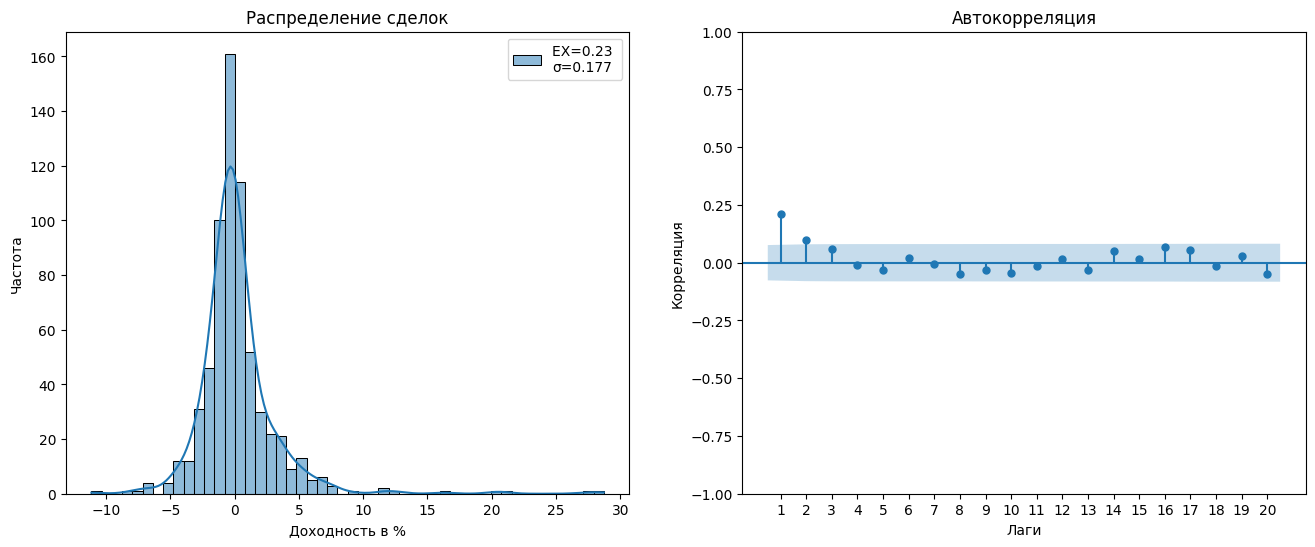

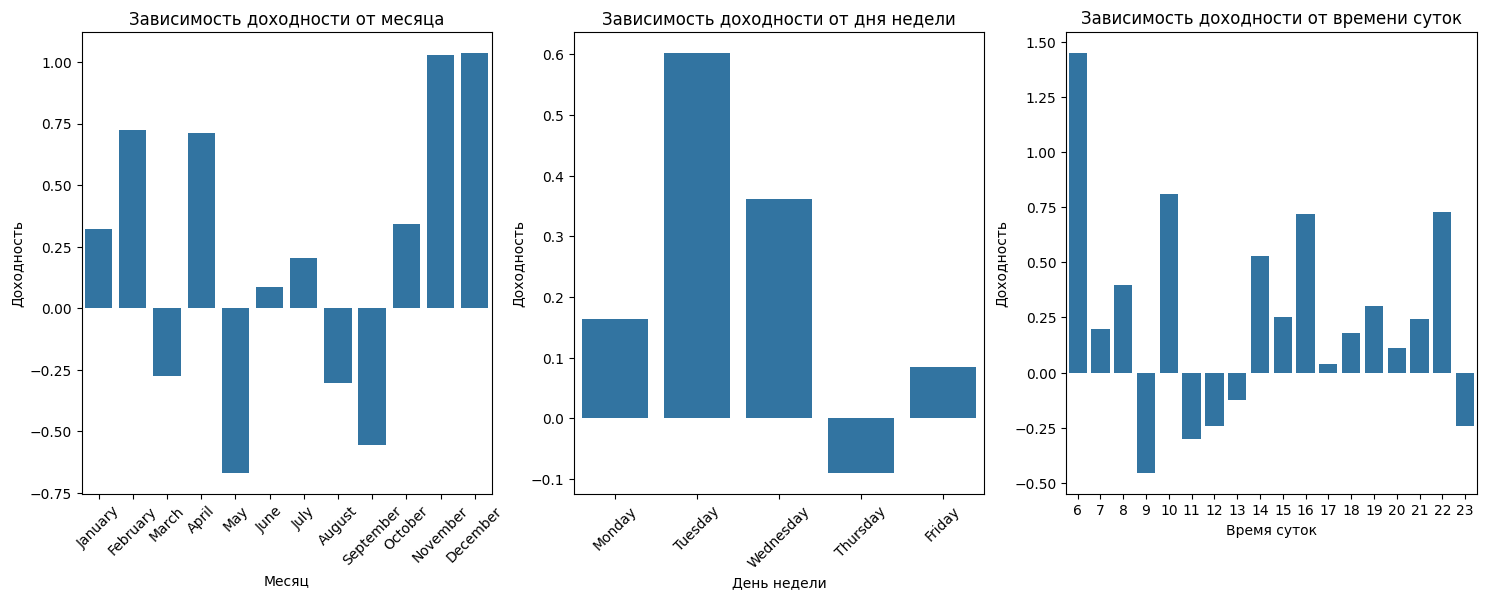

In [134]:
# Функция для глубокого статистического анализа паттернов
def deep_statistics(data, indx):
    """
    Функция предназначена для глубокого статистического анализа торговых стратегий.
    Алгоритм расчитывает:
    - График распределения доходностей и автокорреляцию
    - Проверку на стационарность
    - Проверку на автокорреляцию
    - Проверку на Нормальность
    - Сравнение средней доходности с 0
    - Анализ временных факторов на доходность

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
        indx (int): индекс стратегии
        
    """
    if len(data) > 0:
        pr_percent_net = data.loc[indx, 'profit percent net']
        # 1. График
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sns.histplot(pr_percent_net * 100, ax=axes[0], bins=50, kde=True, 
                    label=f'EX={np.round(np.mean(pr_percent_net) * 100, 3)} \nσ={np.round(np.sqrt(np.std(pr_percent_net)),3)}')
        axes[0].set_title('Распределение сделок')
        axes[0].set_xlabel('Доходность в %')
        axes[0].set_ylabel('Частота')
        axes[0].legend(fontsize=10)
        plot_acf(pr_percent_net, zero=False, ax=axes[1], lags=20)
        axes[1].set_title('Автокорреляция')
        axes[1].set_xlabel('Лаги')
        axes[1].set_ylabel('Корреляция')
        axes[1].set_xticks(range(1, 21))
        
        # 2. Стационарность
        print('=' * 61)
        print('ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)')
        print('=' * 61)
        result_adfuler = adfuller(pr_percent_net)
        if result_adfuler[1] < 0.05:
            print('Ряд стационарен')
        else:
            print('Ряд нестационарен')
        print()
        
        
        # 3. Тест Льюнг-Бокса
        print('=' * 61)
        print('ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)')
        print('=' * 61)
        
        lb_test = acorr_ljungbox(pr_percent_net, lags=np.arange(1, 6))
        for i in range(1, 6):
            print(f"Лаг {i}: Наличие автокорреляции - {'Да (p ≤ 0.05)' if lb_test.loc[i, 'lb_pvalue'] <= 0.05 else 'Нет (p > 0.05)'}")
        print()

        # 4. Нормальность распределения
        print('=' * 61)
        print('ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)')
        print('=' * 61)
        Anderson_test = anderson(pr_percent_net, dist='norm')
        for i in range(2, len(Anderson_test.significance_level)):
            sl, cv = Anderson_test.significance_level[i], Anderson_test.critical_values[i]
            print(f'Уровень доверия: {sl}%: {"Нормальное распределение" if Anderson_test.statistic < cv else "Распределение Не нормальное"}')
        print()

        # 5. Сравнение с нулевой доходностью.
        print('=' * 61)
        print('СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ')
        print('=' * 61)
        if Anderson_test.statistic < Anderson_test.critical_values[2]:
            distr = 'YES'
            print(f'СРЕДНЯЯ: {np.round(np.mean(pr_percent_net) * 100, 3)}%')
            _, p_value = stats.ttest_1samp(pr_percent_net, popmean=0)
            if p_value < 0.05:
                zero = 'NO'
                print('Средняя значимо отличается от 0')
            else:
                zero = 'YES'
                print('НЕТ оснований утверждать, что средняя значимо отличается от 0')
        else:
            distr = 'NO'
            print(f'МЕДИАНА: {np.round(np.median(pr_percent_net) * 100, 3)}%')
            _, p_value = wilcoxon(pr_percent_net)
            if p_value < 0.05:
                zero = 'NO'
                print('Медиана значимо отличается от 0')
            else:
                zero = 'YES'
                print('НЕТ оснований утверждать, что медиана значимо отличается от 0')
        print()
        
        # 6. Бутстреп
        print('=' * 61)
        print('БУСТРЕП (95%)')
        print('=' * 61)
        n_trades = len(pr_percent_net)
        list_mean = []
        list_median = []
        for i in range(10_000):
            sample = np.random.choice(pr_percent_net, size=n_trades, replace=True)
            median_sample = np.median(sample)
            mean_sample = np.mean(sample)
            list_median.append(median_sample)
            list_mean.append(mean_sample)
            
        mean_bootstrap = np.round(np.mean(list_mean) * 100, 2) 
        mean_lower = np.round(np.percentile(list_mean, q=2.5) * 100, 2)
        mean_upper = np.round(np.percentile(list_mean, q=97.5) * 100, 2)
        prob_mean = np.round(np.mean(np.array(list_mean) < 0) * 100, 1)
        
        median_bootstrap = np.round(np.median(list_median) * 100, 2)
        median_lower = np.round(np.percentile(list_median, q=2.5) * 100, 2)
        median_upper = np.round(np.percentile(list_median, q=97.5) * 100, 2)
        prob_median = np.round(np.mean(np.array(list_median) < 0) * 100, 1)
        print(f'Средняя:   {mean_bootstrap}%    [{mean_lower}%, {mean_upper}%]. Вероятность убыточности: {prob_mean}%')
        print(f'Медиана:   {median_bootstrap}%  [{median_lower}%, {median_upper}%]. Вероятность убыточности: {prob_median}%')
        
        # 7. Удаление 5% самых больших убытков и 5% самых больших прибылей
        five_upper = np.quantile(pr_percent_net, 0.95)
        five_lower = np.quantile(pr_percent_net, 0.05)
        pr_percent_net_blowout = pr_percent_net[(five_lower < pr_percent_net) & (pr_percent_net < five_upper)]
        # Win rate
        win_rate_n = np.round(np.mean(pr_percent_net > 0) * 100)
        win_rate_blowout = np.round(np.mean(pr_percent_net_blowout > 0) * 100)
        
        # Средние и медианы
        mean_profit_n = np.round(np.mean(pr_percent_net) * 100, 2)
        mean_profit_blowout = np.round(np.mean(pr_percent_net_blowout) * 100, 2)
        median_profit_n = np.round(np.median(pr_percent_net) * 100, 2)
        median_profit_blowout = np.round(np.median(pr_percent_net_blowout) * 100, 2)
        
        # Профит фактор
        profit_factor_n = np.round(np.sum(pr_percent_net[pr_percent_net > 0]) / np.abs(np.sum(pr_percent_net[pr_percent_net < 0])), 2)
        profit_factor_blowout = np.round(np.sum(pr_percent_net_blowout[pr_percent_net_blowout > 0]) / np.abs(np.sum(pr_percent_net_blowout[pr_percent_net_blowout < 0])), 2)
        
        # Сравнение с нулевой доходностью
        Anderson_test_blowout = anderson(pr_percent_net_blowout, dist='norm')
        if Anderson_test_blowout.statistic < Anderson_test_blowout.critical_values[2]:
            distr_blowout = 'YES'
            _, p_value_b = stats.ttest_1samp(pr_percent_net_blowout, popmean=0)
            if p_value_b < 0.05:
                zero_b = 'NO'
            else:
                zero_b = 'YES'
        else:
            distr_blowout = 'NO'
            _, p_value_b = wilcoxon(pr_percent_net_blowout)
            if p_value_b < 0.05:
                zero_b = 'NO'
            else:
                zero_b = 'YES'
        print()
        
        # Собираем всё вместе в табличку
        dict_normal = {'winrate (%)' : win_rate_n, 'mean return (%)' : mean_profit_n, 'median return (%)' : median_profit_n, 
                    'profit factor' : profit_factor_n,
                    'Normal dist?' : distr, 'p-value (= 0?)' : np.round(p_value, 3), '= 0?' : zero}
        dict_blowout = {'winrate (%)' : win_rate_blowout, 'mean return (%)' : mean_profit_blowout, 'median return (%)' : median_profit_blowout, 
                        'profit factor' : profit_factor_blowout,
                    'Normal dist?' : distr_blowout, 'p-value (= 0?)' : np.round(p_value_b, 3), '= 0?' : zero_b}
        df = pd.DataFrame({'Normal' : dict_normal, 'Without outliers' : dict_blowout})
        print(skew(pr_percent_net))
        display(df)
        

        # 6 Временной анализ
        data_percent = (pr_percent_net * 100).to_frame().reset_index()
        data_percent['time'] = pd.to_datetime(data_percent['time'])
        data_percent['Month'] = data_percent['time'].dt.month_name()
        data_percent['day_of_week'] = data_percent['time'].dt.day_name()
        data_percent['hour'] = data_percent['time'].dt.hour
        
        # Группировка
        months = ['January', 'February', 'March', 'April', 'May', 'June',
            'July', 'August', 'September', 'October', 'November', 'December']
        weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
        data_percent_group_month = data_percent.groupby('Month')['profit_percent_net'].mean().reset_index()
        data_percent_group_day_of_week = data_percent.groupby('day_of_week')['profit_percent_net'].mean().reset_index()
        data_percent_group_hour = data_percent.groupby('hour')['profit_percent_net'].mean().reset_index()
        
        # График 
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # 1
        sns.barplot(data_percent_group_month, x=data_percent_group_month['Month'], y=data_percent_group_month['profit_percent_net'], ax=axes[0],
                    order=months)
                    
        axes[0].set_title('Зависимость доходности от месяца')
        axes[0].set_xlabel('Месяц')
        axes[0].set_ylabel('Доходность')
        axes[0].set_xticklabels(labels=months, rotation=45)
        
        # 2
        sns.barplot(data_percent_group_day_of_week, x=data_percent_group_day_of_week['day_of_week'], y=data_percent_group_day_of_week['profit_percent_net'], ax=axes[1],
                    order=weekdays)
        axes[1].set_title('Зависимость доходности от дня недели')
        axes[1].set_xlabel('День недели')
        axes[1].set_ylabel('Доходность')
        axes[1].set_xticklabels(labels=weekdays, rotation=45)
        
        # 3
        sns.barplot(data_percent_group_hour, x=data_percent_group_hour['hour'], y=data_percent_group_hour['profit_percent_net'], ax=axes[2])
        axes[2].set_title('Зависимость доходности от времени суток')
        axes[2].set_xlabel('Время суток')
        axes[2].set_ylabel('Доходность')
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')

    
result_statistics = deep_statistics(res, 2)

In [135]:
skew

<function scipy.stats._stats_py.skew(a, axis=0, bias=True, nan_policy='propagate', *, keepdims=False)>

In [136]:
import pickle

In [137]:
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_1candle.pkl', 'wb') as file:
    pickle.dump(res, file)